# Data Loading 
Before loading make sure to define file paths

In [ ]:
csv_path = r"" 

Import necessary packages

In [2]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

In [3]:
flat_df = pd.read_csv(csv_path)
print(flat_df.head())

                Country  Metadata_Capital  Metadata_Population  \
0               Andorra  Andorra la Vella                84000   
1  United Arab Emirates         Abu Dhabi              4975593   
2           Afghanistan             Kabul             29121286   
3   Antigua and Barbuda        St. John's                86754   
4              Anguilla        The Valley                13254   

   Metadata_Area (km^2)  
0                 468.0  
1               82880.0  
2              647500.0  
3                 443.0  
4                 102.0  


In [4]:
conn = sqlite3.connect('workshop.db')
cursor = conn.cursor()
flat_df.to_sql('flat_df', conn, if_exists='replace', index=False)

250

In [5]:
# The column names are not in standard sql syntax
flat_df.columns

Index(['Country', 'Metadata_Capital', 'Metadata_Population',
       'Metadata_Area (km^2)'],
      dtype='object')

In [6]:
cursor.executescript("""
ALTER TABLE flat_df RENAME COLUMN "Metadata_Area (km^2)" TO "metadata_area_km2";
ALTER TABLE flat_df RENAME COLUMN "Metadata_Population" TO "metadata_population";
ALTER TABLE flat_df RENAME COLUMN "Country" TO "country";
               """);

### Deleting a table from the Database

In [7]:
# This code will delete a table that already exists.
cursor.execute("DROP TABLE IF EXISTS iris_data");
cursor.execute("DROP TABLE IF EXISTS flat_df_cleaned");

##### What if you do not have data or you want to manual create database without using


df.to_sql('flat_df', conn, if_exists='replace', index=False)

In [8]:
cursor.execute("""
    CREATE TABLE flat_df_cleaned (
    country TEXT PRIMARY KEY,
    metadata_capital TEXT,
    metadata_population INTEGER,
    metadata_area_km2 REAL
);
""")
               

### Inserting into database

In [9]:
cursor.execute("""
               INSERT INTO flat_df_cleaned (country, metadata_capital, metadata_population, "metadata_area_km2")
               VALUES ('SDSLand', 'SDS City', 1000000, 20000);
               """)

### Multiple inserts into database

In [10]:
query = """
INSERT INTO flat_df_cleaned 
(country, metadata_capital, metadata_population, "metadata_area_km2") 
VALUES (?, ?, ?, ?);
"""
data_for_db = (
    ('Theplace', 'Theplace City', 5000000, 10000),
    ('Gotham', 'Gotham City', 7500000, 15000),
    ('Freeman', 'Freeman City', 3000000, 5000)
)

In [11]:

cursor.executemany(query, data_for_db)
conn.commit()

### Modifying an existing sql table

In [12]:
cursor.execute("""
            ALTER TABLE flat_df_cleaned 
            ADD COLUMN region TEXT;
            """)
conn.commit()

In [13]:
cursor.execute("""
               ALTER TABLE flat_df_cleaned 
               DROP COLUMN metadata_capital;
               """)
conn.commit()

### Updating an existing row


In [14]:
cursor.execute("""
              UPDATE flat_df_cleaned 
              SET metadata_population = 5500000 WHERE country = 'Gotham City';
              """)
conn.commit()

### Deleting a record from the sql table

In [15]:
cursor.execute("DELETE FROM flat_df_cleaned WHERE country = 'Theplace'")
conn.commit()

## Useful Guides
https://www.geeksforgeeks.org/sql/sql-tutorial/

https://www.datacamp.com/cheat-sheet/sql-basics-cheat-sheet

## Practice

In [16]:
import pandas as pd
import sqlite3
from sklearn.datasets import load_iris

iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target



In [ ]:
# Load the dataset into a database
# Do not use flat_df or flat_df_cleaned

conn = sqlite3.connect('workshop.db')

# Create a new table for the iris dataset and insert the data
df_iris.XXXX('iris_data', XXXX, if_exists='replace', index=False)


150

In [ ]:
# Rename the columns of the iris dataset to be more SQL-friendly
cursor.XXXX("""
ALTER TABLE iris_data RENAME COLUMN XXXXXXX;
ALTER TABLE iris_data RENAME COLUMN XXXXXXX;
ALTER TABLE iris_data RENAME COLUMN XXXXXXX;
ALTER TABLE iris_data RENAME COLUMN XXXXXXX;
ALTER TABLE iris_data RENAME COLUMN XXXXXXX;                
               """)

Extract 

1. Sepal Length 5.0

2. Petal length between 3.0 and 6cm


In [ ]:
# Extract to a dataframe where 
# Sepal Length > 5.0
# Petal length between 3.0 and 6.0cm

query = ("""
XXXXXXXX
""")
result = pd.read_sql_query(query, conn)
print(result.shape)

(87, 5)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

X = result.drop(columns=['petal_type']) # Change this to the correct output variable name if you named it differently
y = result['petal_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      0.88      0.93         8
           2       0.91      1.00      0.95        10

    accuracy                           0.94        18
   macro avg       0.95      0.94      0.94        18
weighted avg       0.95      0.94      0.94        18



In [21]:
results_df = X_test.copy()
results_df['actual_petal_type'] = y_test
results_df['predicted_petal_type'] = y_pred

print(results_df.head())

    sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
76              6.9             3.1              5.4             2.1   
0               7.0             3.2              4.7             1.4   
26              6.0             2.9              4.5             1.5   
22              6.4             2.9              4.3             1.3   
12              5.6             2.9              3.6             1.3   

    actual_petal_type  predicted_petal_type  
76                  2                     2  
0                   1                     1  
26                  1                     1  
22                  1                     1  
12                  1                     1  


In [ ]:
# Save the results back to the database
results_df.to_sql(
    name='iris_predictions', 
    con=conn, 
    if_exists='append', 
    index=False         
)

conn.commit()  

Visualise Predictions

In [ ]:
# Extract the predictions back to a dataframe
query = ("""
XXXXXXXX
""")

predictions = pd.read_sql_query(query, conn)

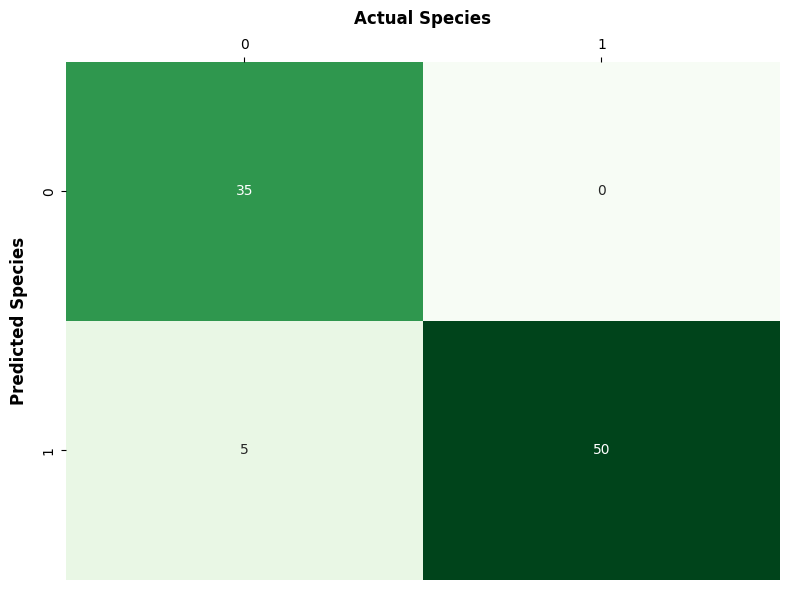

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

actual = predictions['actual_petal_type']
predicted = predictions['predicted_petal_type']

cm = confusion_matrix(actual, predicted)
plt.figure(figsize=(8, 6))
plot = sns.heatmap(
    cm.T, 
    annot=True,         
    fmt='d',             
    cmap='Greens',     
    cbar=False,    
)

plot.xaxis.tick_top()
plot.xaxis.set_label_position('top')

plt.xlabel('Actual Species', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Predicted Species', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()